# Fundamentos del Análisis de Datos - Cursada 2026 (UNICEN)
## Práctico 6: Tests de Hipótesis

**Estudiante:** Facha  
**Metodología y Protocolo de Inferencia Estadística:**
1. **Diagnóstico conceptual y clasificación de variables:** Identificar variable respuesta y factor de agrupación, nivel de medición (cualitativa nominal/ordinal, cuantitativa discreta/continua).
2. **Formulación de Hipótesis:** Definir formalmente $H_0$ y $H_1$, estableciendo si el test es bilateral o unilateral en función del objetivo sustantivo.
3. **Verificación rigurosa de supuestos:** Evaluar normalidad (Shapiro-Wilk, Q-Q plots, asimetría), homocedasticidad (Levene) e independencia de las muestras.
4. **Selección y ejecución del test:** Seleccionar la prueba adecuada (t de Student / Welch vs Mann-Whitney U / Wilcoxon / Kruskal-Wallis / ANOVA / Chi-cuadrado) según cumplimiento de supuestos.
5. **Visualización e interpretación analítica (*"So What?"*):** Representación gráfica honesta (boxplots con `notch=True`, scatter plots 1:1, etc.), análisis de significancia estadística vs relevancia práctica y discusión de causalidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Configuración de estilo y estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Entorno tp6 y librerías cargadas exitosamente.")

Entorno tp6 y librerías cargadas exitosamente.


---
## Ejercicio 1: Expectativa de Vida (OMS / WHO)
Dataset: `Life Expectancy Data.csv`

**Consignas:**
- **a.** Realizar todo el preprocesamiento necesario sobre todas las columnas.

In [7]:
# Carga y primera inspección de los datos
df_lifeExpec = pd.read_csv('Life Expectancy Data.csv')
print(f"Dimensiones: {df_lifeExpec.shape}")

df_lifeExpec.head()

Dimensiones: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
df_lifeExpec.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [16]:
#Quiero saber el porcentaje de nulos por columna 
df_lifeExpec.isna().mean() * 100

Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
 BMI                                1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
 HIV/AIDS                           0.000000
GDP                                15.248468
Population                         22.191967
 thinness  1-19 years               1.157250
 thinness 5-9 years                 1.157250
Income composition of resources     5.684139
Schooling                           5.547992
dtype: flo

### Consigna 1.a: Preprocesamiento de Datos y Auditoría de Nulos

**Estrategia metodológica:**
1. **Sanitización de identificadores:** Eliminar espacios en blanco iniciales/finales de los nombres de columnas con `.str.strip()` (ej. `'Life expectancy '` $\to$ `'Life expectancy'`).
2. **Depuración de la variable respuesta:** Descartar las 10 filas (0.34%) donde `Life expectancy` es nula, ya que es la variable objetivo principal y su ausencia imposibilita la inferencia sobre esas unidades.
3. **Ordenamiento cronológico:** Ordenar el panel por `Country` y `Year` para asegurar la coherencia temporal de las series.
4. **Interpolación intra-país:** Interpolar linealmente dentro de cada país (`groupby('Country')`) y aplicar `.bfill()` / `.ffill()` hacia los extremos de la serie temporal para respetar la inercia histórica de cada nación.
5. **Tratamiento ético de nulos remanentes:** Aquellos países que no registran información en todo el período (ej. PBI en países sin estadísticas oficiales de la OMS) se preservan como `NaN` para excluirlos puntualmente en el test correspondiente (*pairwise deletion*), evitando inventar valores que distorsionen los contrastes de hipótesis.

In [18]:
# 1. Sanitizar nombres de columnas
df_clean = df_lifeExpec.copy()
df_clean.columns = df_clean.columns.str.strip()

# 2. Descartar filas sin variable respuesta (Life expectancy)
df_clean = df_clean.dropna(subset=['Life expectancy']).copy()

# 3. Ordenar cronológicamente por país y año
df_clean = df_clean.sort_values(by=['Country', 'Year']).reset_index(drop=True)

# 4. Interpolación temporal intra-país (con bfill y ffill en los bordes)
num_cols = df_clean.select_dtypes(include='number').columns.drop('Year')
df_clean[num_cols] = df_clean.groupby('Country')[num_cols].transform(
    lambda grp: grp.interpolate(method='linear').bfill().ffill()
)

print(f"Dimensiones iniciales: {df_lifeExpec.shape}")
print(f"Dimensiones tras limpieza: {df_clean.shape}")
print("\nNulos remanentes por columna:")
nulls_rem = df_clean.isna().sum()
print(nulls_rem[nulls_rem > 0])

Dimensiones iniciales: (2938, 22)
Dimensiones tras limpieza: (2928, 22)

Nulos remanentes por columna:
Alcohol                             16
Hepatitis B                        144
BMI                                 32
Total expenditure                   32
GDP                                400
Population                         640
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64


- **b.** Comprobar gráfica y estadísticamente si los países desarrollados tienen un producto per cápita mayor al de los en vías de desarrollo. Seleccionar el mejor test en función del objetivo y el cumplimiento de los supuestos.

/tmp/ipykernel_219438/4107195336.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


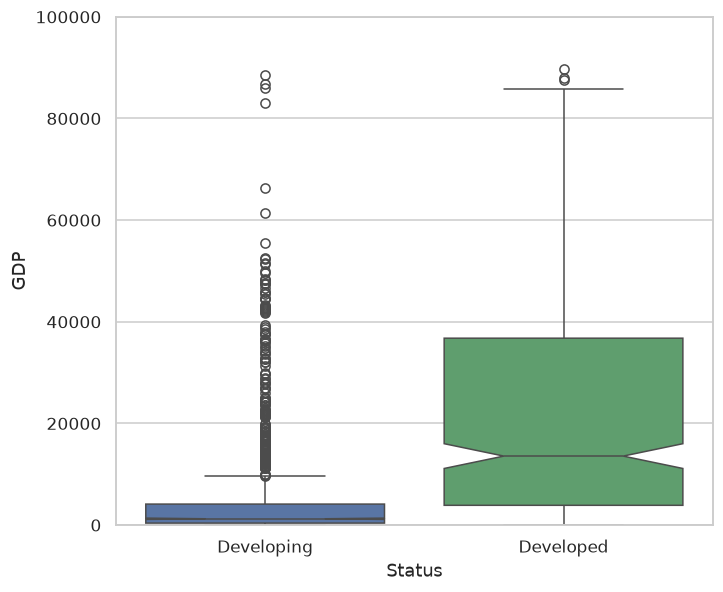

In [27]:
# 1.b - Preparación de subconjuntos excluyendo nulos en GDP (pairwise deletion)
df_gdp = df_clean.dropna(subset=['GDP'])

gdp_dev = df_gdp[df_gdp['Status'] == 'Developed']['GDP']
gdp_ing = df_gdp[df_gdp['Status'] == 'Developing']['GDP']


# Visualización comparativa honesta
plt.figure(figsize=(7,6))

# Boxplot con muescas (notches)
sns.boxplot(
    data=df_gdp, 
    x='Status', 
    y='GDP', 
    palette=['#4C72B0', '#55A868'], 
    notch=True, 
)
plt.ylim([0, 100000])
plt.show()

# Analisis
Al graficar los boxplot con las muezcas, se ve claramente que no se solapan. Las muestras representan un intervalo de confianza del 95% sobre el valor de la mediana. Si ni siquiera con este margen se llegan a solapar, nos da confianza para creer que las medianas de las poblaciones son distintas.

Lo que sigue ahora es testear. 

Como son 2 muestras independientes, buscaremos hacer un test t, donde se tiene que cumplir normalidad y homoscedasticidad


Para normalidad tenemos dos opciones:
* Shapiro-wilk 
* Kolmogorov-Smirnov. 

Recordemos que la hipótesis nula es la normalidad de los datos. En consecuencia, si el p-valor que obtenemos es menor a nuestro nivel de confianza $\alpha$ (normalmente $\alpha=0.05$), estamos entonces ante datos que no respetan una distribución normal:

A diferencia del Shapiro-Wilk, Kolmogorov-Smirnov es más general y menos potente para detectar desviaciones sutiles de normalidad, pero puede aplicarse a muestras más grandes.

In [29]:
from scipy.stats import shapiro

# Test de Shapiro-Wilk para países desarrollados
stat, p = shapiro(gdp_dev)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Test de Shapiro-Wilk para países en vías de desarrollo
stat, p = shapiro(gdp_ing)
print(f"Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")



Test de Shapiro-Wilk para países desarrollados: Estadístico=0.844, p-valor=0.000
Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico=0.484, p-valor=0.000


In [30]:
from scipy.stats import kstest

# Test de Kolmogorov-Smirnov para países desarrollados
stat, p = kstest(gdp_dev, 'norm')
print(f"Test de Kolmogorov-Smirnov para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Test de Kolmogorov-Smirnov para países en vías de desarrollo
stat, p = kstest(gdp_ing, 'norm')
print(f"Test de Kolmogorov-Smirnov para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Kolmogorov-Smirnov para países desarrollados: Estadístico=1.000, p-valor=0.000
Test de Kolmogorov-Smirnov para países en vías de desarrollo: Estadístico=0.999, p-valor=0.000


Se rechaza la hipotesis nula que plantea normalidad. Por lo tanto los datos no se distribuyen normal

#### 3.1.3 - Validamos homocedasticidad

Se refiere a que las varianzas de los grupos que se están comparando deben ser aproximadamente iguales. En otras palabras, la dispersión o variabilidad de los datos dentro de cada grupo debe ser similar.

Los tests que tenemos disponibles son el de Levene (que es más robusto para distribuciones que no son normales) y el de Bartlett (que funciona en distribuciones normales).

En Levene la hipótesis nula es que las varianzas son similares entre sí (hay heterocedasticidad), por lo que pedimos que el test nos de un p-valor mayor a 0.05:

In [32]:
stat, p = stats.levene(gdp_dev, gdp_ing)
print(f"Test de Levene para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Levene para GDP_per_capita: Estadístico=637.415, p-valor=0.000


#### 3.1.4 - Validamos la hipótesis con Kruskal-Wallis

Dado que nuestro conjunto no cumple con ninguno de los supuestos que se necesitan para realizar la comparación de estos grupos, vamos a tener que recurrir al test de Kruskal-Wallis. La hipótesis nula del test es que no existen diferencias significativas entre los dos grupos provistos. Por consiguiente, si el p-valor del test nos da por debajo del umbral de significancia (acá abajo les puse una variable ```alpha``` en 0.05 para controlar eso), efectivamente hay una diferencia significativa entre ambos.

In [33]:
# Test de Kruskal-Wallis para comparar GDP_per_capita entre países desarrollados y en vías de desarrollo
stat, p = stats.kruskal(gdp_dev, gdp_ing)
print(f"Test de Kruskal-Wallis para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para GDP_per_capita: Estadístico=473.370, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.


# Validamos que las medianas son diferentes
Pero ahora queremos conocer cual es mayor

In [36]:
from scipy.stats import mannwhitneyu

# alternative='greater' testea formalmente si Developed > Developing
stat, p = mannwhitneyu(gdp_dev, gdp_ing, alternative='greater')
print(f"Mann-Whitney U (unilateral): Estadístico={stat:.1f}, p-valor={p:.4e}")

if p < 0.05:
    print("Se rechaza h0, se valida que los desarrollados tienen una mediana mayor")

Mann-Whitney U (unilateral): Estadístico=770818.0, p-valor=2.9637e-105
Se rechaza h0, se valida que los desarrollados tienen una mediana mayor



- **c.** Comprobar gráfica y estadísticamente si los países en vías de desarrollo gastan un menor porcentaje de su producto bruto en salud que los países desarrollados.

/tmp/ipykernel_219438/3852903113.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


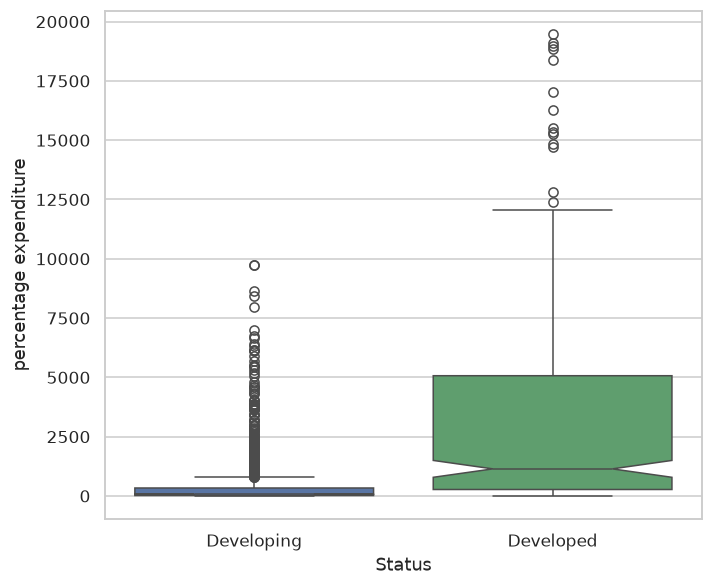

In [ ]:
# 1.c - Preparación de subconjuntos 
expend_dev = df_gdp[df_gdp['Status'] == 'Developed']['percentage expenditure']
expend_ing = df_gdp[df_gdp['Status'] == 'Developing']['percentage expenditure']
# Visualización comparativa honesta
plt.figure(figsize=(7,6))

# Boxplot con muescas (notches)
sns.boxplot(
    data=df_gdp, 
    x='Status', 
    y='percentage expenditure', 
    palette=['#4C72B0', '#55A868'], 
    notch=True, 
)
#plt.ylim([0, 20000])
plt.show()


- **d.** Comprobar gráfica y estadísticamente si los países en vías de desarrollo tienen una expectativa de vida menor a los desarrollados.

/tmp/ipykernel_219438/559525386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


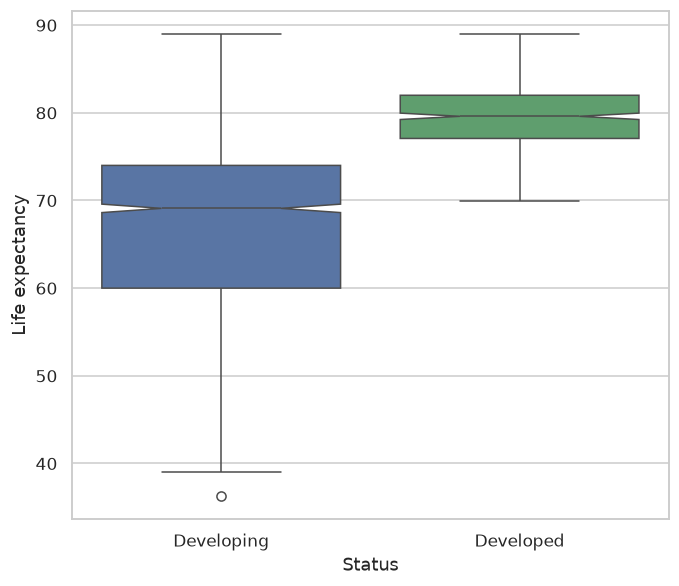

In [50]:
# Preparacion subconjuntos
expectancy_dev = df_clean[df_clean['Status'] == 'Developed']['Life expectancy']
expectancy_ing = df_clean[df_clean['Status'] == 'Developing']['Life expectancy']

# Visualización comparativa honesta
plt.figure(figsize=(7,6))

# Boxplot con muescas (notches)
sns.boxplot(
    data=df_gdp, 
    x='Status', 
    y='Life expectancy', 
    palette=['#4C72B0', '#55A868'], 
    notch=True, 
)
#plt.ylim([0, 100000])
plt.show()

# Normalidad

In [51]:
from scipy.stats import shapiro

# Test de Shapiro-Wilk para países desarrollados
stat, p = shapiro(expectancy_dev)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

if p < 0.05:
    print("Se rechaza h0, NO DISTRIBUYE NORMAL")

# Test de Shapiro-Wilk para países en vías de desarrollo
stat, p = shapiro(expectancy_ing)
print(f"Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")
if p < 0.05:
    print("Se rechaza h0, NO DISTRIBUYE NORMAL")


Test de Shapiro-Wilk para países desarrollados: Estadístico=0.984, p-valor=0.000
Se rechaza h0, NO DISTRIBUYE NORMAL
Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico=0.950, p-valor=0.000
Se rechaza h0, NO DISTRIBUYE NORMAL


# HOMOCEDASTICIDAD

In [52]:
stat, p = stats.levene(expectancy_dev, expectancy_ing)
print(f"Test de Levene para life expectancy: Estadístico={stat:.3f}, p-valor={p:.3f}")
if p < 0.05:
    print("Se rechaza h0, LAS VARIANZAS NO SON SEMEJANTES, no se cumple homocedasticidad")

Test de Levene para life expectancy: Estadístico=286.262, p-valor=0.000
Se rechaza h0, LAS VARIANZAS NO SON SEMEJANTES, no se cumple homocedasticidad


# Entonces Kruskal-Wallis

In [53]:
# Test de Kruskal-Wallis para comparar life expectancy entre países desarrollados y en vías de desarrollo
stat, p = stats.kruskal(expectancy_dev, expectancy_ing)
print(f"Test de Kruskal-Wallis para life expectancy: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en life expectancy entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en life expectancy entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para life expectancy: Estadístico=871.734, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en life expectancy entre países desarrollados y en vías de desarrollo.


# Cual es menor?

In [56]:
from scipy.stats import mannwhitneyu

# alternative='greater' testea formalmente si Developed > Developing
stat, p = mannwhitneyu(expectancy_dev, expectancy_ing, alternative='less')
print(f"Mann-Whitney U (unilateral): Estadístico={stat:.1f}, p-valor={p:.4e}")

if p > 0.05:
    print("Se acepta h0, se valida que los paises en desarrollo tienen una mediana menor")

Mann-Whitney U (unilateral): Estadístico=1131521.0, p-valor=1.0000e+00
Se acepta h0, se valida que los paises en desarrollo tienen una mediana menor



- **e.** ¿Hay una relación entre la combinación de las variables producto per cápita y porcentaje invertido en salud y la expectativa de vida?